Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total images found: 47


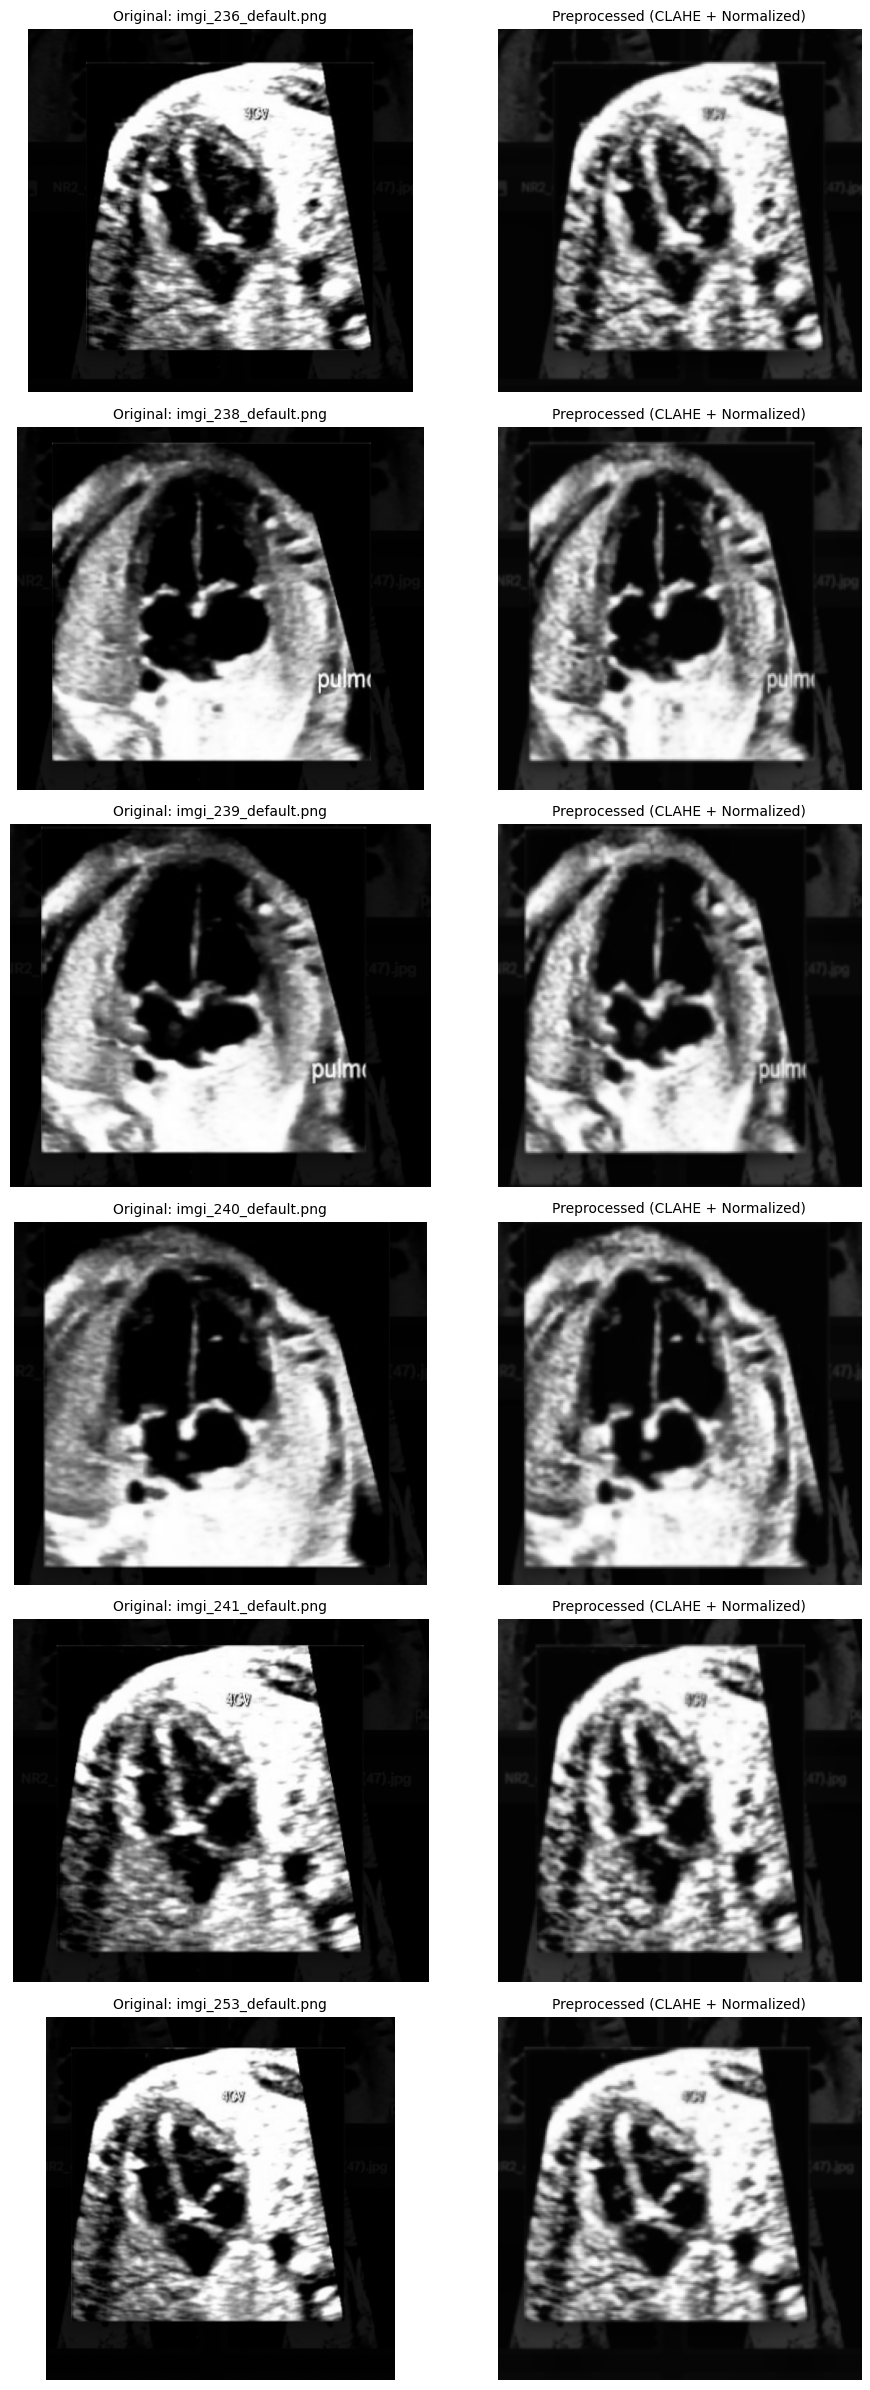

In [1]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# -------------------------------------------------------------------------
# Step 1: Mount Google Drive
# -------------------------------------------------------------------------
drive.mount('/content/drive')

# UPDATE THIS PATH to where your images are stored in Google Drive
# Example: '/content/drive/MyDrive/Fetal_CHD_Dataset'
DATASET_PATH = '/content/drive/MyDrive/chd_data'

# Target image size for Deep Learning models (e.g., ResNet, EfficientNet)
IMG_SIZE = (224, 224)


# -------------------------------------------------------------------------
# Step 2: Define Medical Image Preprocessing Function
# -------------------------------------------------------------------------
def preprocess_fetal_image(image_path, target_size=IMG_SIZE):
    """
    Loads an ultrasound image, applies CLAHE for contrast enhancement,
    resizes it, and normalizes pixel intensities.
    """
    # Read image in grayscale (ultrasound scans are single-channel structural images)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")

    # 1. CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # Enhances local contrast in fetal heart chambers and valves
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img)

    # 2. Gaussian Blur to reduce speckle noise typical in ultrasound
    img_denoised = cv2.GaussianBlur(img_clahe, (3, 3), 0)

    # 3. Resize to model input dimensions
    img_resized = cv2.resize(img_denoised, target_size, interpolation=cv2.INTER_AREA)

    # 4. Normalize pixel values to range [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    # Convert 1-channel grayscale to 3-channel (RGB) for pre-trained CNN backbones
    img_rgb = np.stack((img_normalized,) * 3, axis=-1)

    return img, img_rgb


# -------------------------------------------------------------------------
# Step 3: Load and Preprocess Sample Images
# -------------------------------------------------------------------------
# Gather all image paths (supports jpg, jpeg, png)
valid_extensions = ('*.jpg', '*.jpeg', '*.png', '*.PNG', '*.JPG')
image_paths = []
for ext in valid_extensions:
    image_paths.extend(glob.glob(os.path.join(DATASET_PATH, '**', ext), recursive=True))

print(f"Total images found: {len(image_paths)}")

if len(image_paths) == 0:
    print("⚠️ No images found. Please check your DATASET_PATH in Google Drive.")
else:
    # -------------------------------------------------------------------------
    # Step 4: Visualize Original vs. Preprocessed Images
    # -------------------------------------------------------------------------
    # Display up to 6 sample images for visual comparison
    num_samples = min(6, len(image_paths))
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_samples):
        path = image_paths[i]
        filename = os.path.basename(path)

        orig_img, prep_img = preprocess_fetal_image(path)

        # Original Image
        axes[i, 0].imshow(orig_img, cmap='gray')
        axes[i, 0].set_title(f"Original: {filename}", fontsize=10)
        axes[i, 0].axis('off')

        # Preprocessed Image
        axes[i, 1].imshow(prep_img)
        axes[i, 1].set_title("Preprocessed (CLAHE + Normalized)", fontsize=10)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()